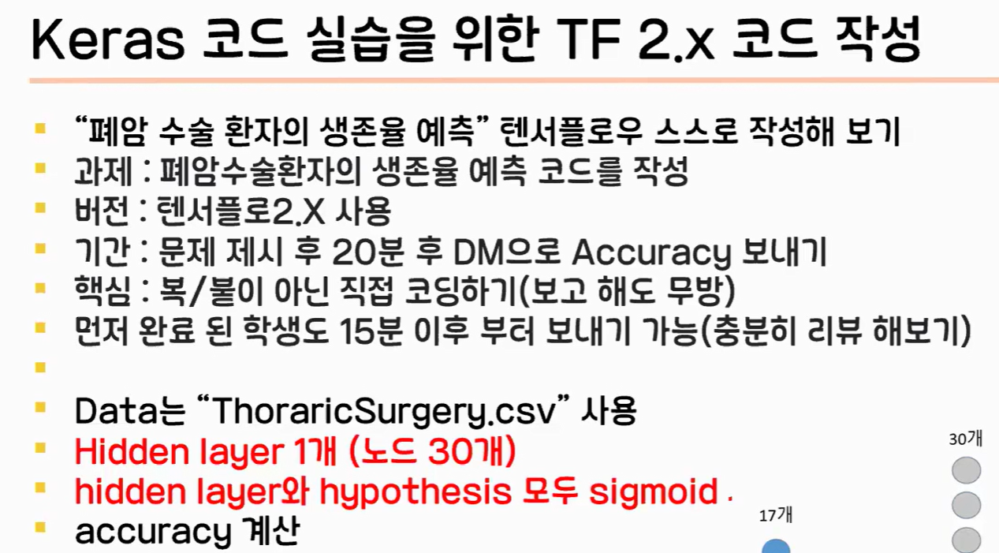

In [ ]:
import tensorflow as tf
import numpy as np

# 난수 고정을 위한 시드(seed) 설정
tf.random.set_seed(0)
np.random.seed(0)

# 1. 데이터 불러오기
Data_set = np.loadtxt("ThoraricSurgery.csv", delimiter=",")
# x_data: 환자의 기록 (17개 특성)
# y_data: 수술 결과 (생존 여부) - 0 또는 1
x_data = Data_set[:, 0:17].astype(np.float32)
y_data = Data_set[:, [17]].astype(np.float32)

# 2. 모델에 사용할 학습 파라미터(가중치, 편향) 정의
W1 = tf.Variable(tf.random.normal([17, 30]), name='W1')
b1 = tf.Variable(tf.random.normal([30]),     name='b1')
W2 = tf.Variable(tf.random.normal([30, 1]),  name='W2')
b2 = tf.Variable(tf.random.normal([1]),      name='b2')

# 3. forward 연산(순전파) 정의
def forward(X):
    # X shape: [batch_size, 17]
    # hidden_layer shape: [batch_size, 30]
    # hypothesis shape: [batch_size, 1]
    hidden_layer = tf.sigmoid(tf.matmul(X, W1) + b1)
    hypothesis   = tf.sigmoid(tf.matmul(hidden_layer, W2) + b2)
    return hypothesis

# 4. 비용 함수 정의 (로지스틱 회귀 비용 함수)
def loss_fn(X, Y):
    # -( Y*log(h(x)) + (1-Y)*log(1-h(x)) )를 배치 평균으로 계산
    # 예측
    hypothesis = forward(X)
    cost = -tf.reduce_mean(Y * tf.math.log(hypothesis) + (1 - Y) * tf.math.log(1 - hypothesis))
    return cost

# 5. 최적화 알고리즘 설정
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1)

# 6. 학습 루프 (GradientTape 사용)
for step in range(10001):
    with tf.GradientTape() as tape:
        cost = loss_fn(x_data, y_data)
    # 미분(Gradient) 계산
    grads = tape.gradient(cost, [W1, b1, W2, b2])
    # 업데이트
    optimizer.apply_gradients(zip(grads, [W1, b1, W2, b2]))

    # 중간 비용 출력
    if step % 1000 == 0:
        print(f"Step {step}, Cost: {cost.numpy():.6f}")

# 7. 정확도 평가
# 예측값이 0.5 보다 크면 1(True), 아니면 0(False)
prediction = forward(x_data)
predicted_class = tf.cast(prediction > 0.5, dtype=tf.float32)
accuracy = tf.reduce_mean(tf.cast(tf.equal(predicted_class, y_data), dtype=tf.float32))
print("\nTraining Accuracy:", accuracy.numpy())

# 8. 새로운 데이터로 예측하기 (사망 Data(0))
new_data = np.array([[132, 2, 2.12, 1.72, 1, 0, 0, 0, 0, 0, 12, 0, 0, 0, 1, 0, 74]], dtype=np.float32)
new_prediction = forward(new_data)
new_predicted_class = tf.cast(new_prediction > 0.5, dtype=tf.float32)

print(" \nNew Data Prediction (Probability): ", new_prediction.numpy())
print(" New Data Predicted Class: ", new_predicted_class.numpy())

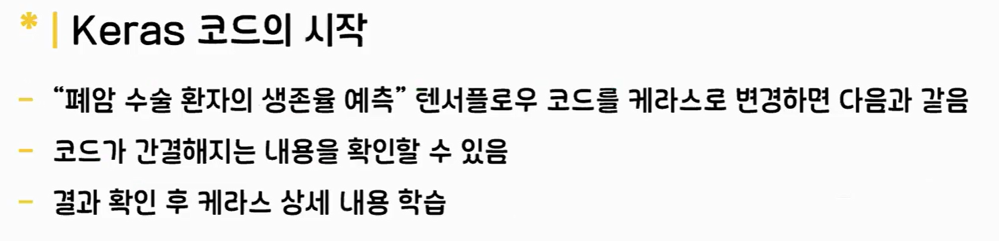

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import numpy as np
import tensorflow as tf

seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# 준비된 수술 환자 데이터를 불러들입니다.
Data_set = np.loadtxt('ThoraricSurgery.csv', delimiter=",")
# 환자의 기록과 수술 결과를 X와 Y로 구분하여 저장합니다.
X = Data_set[:, 0:17]
Y = Data_set[:, 17]

# 딥러닝 구조를 결정합니다.
model = Sequential() # 신겸망 구조 정의 : 순서대로 층 추가
model.add(Input(shape=(17,)))
model.add(Dense(30, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# 딥러닝을 실행합니다.
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X, Y, epochs=30, batch_size=10)

# 결과를 출력합니다.
print("\n Accuracy : %4f" % (model.evaluate(X, Y)[1])) # evluate 결과값 [0] : loss, [1] : accuracy

# 예측
input_data = np.array([[132, 2, 2.12, 1.72, 1, 0, 0, 0, 0, 0, 12, 0, 0, 0, 1, 0, 74]], dtype=np.float32)
prediction = m odel.predict(input_data)
print(prediction)

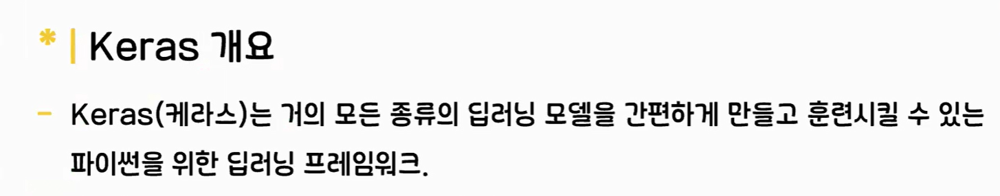

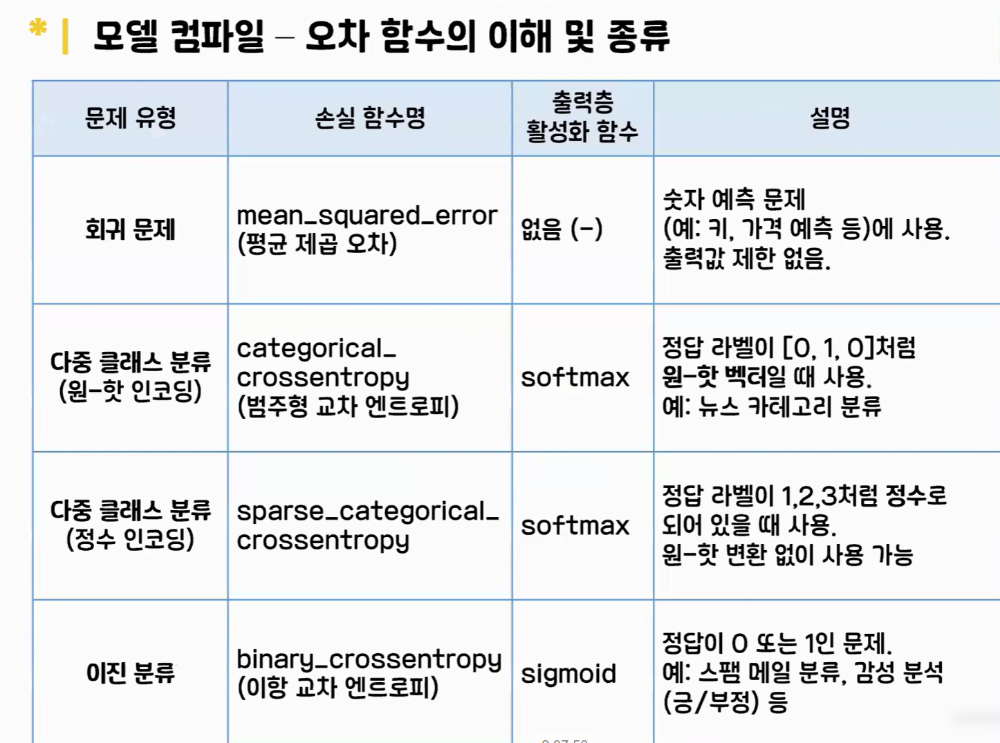

In [ ]:
# 선형, 단항, 다항

In [ ]:
# optimizer(최적화)
# GD -> SGD -> MOMENTUM -> RMSProp -> Adam

In [ ]:
# mean_squared_error  : 평균 제곱 오차
# mean_absolute_error : 평균 절대값 오차
# binary_crossentropy : 이항(단항)교차 엔트로피
# categorical_crossentropy : 범주형(다항)교차 엔트로피

In [ ]:
# 속성
# 클래스

In [ ]:
# 1000개의 데이터에 대해서, 반복문을 다 돌리면 1 epoch
# batch_size는 1000개의 데이터를 몇 개씩 끊어서 가중치 업데이트를 할건지

In [ ]:
# evaluate() : 테스트용 데이터를 통해 학습한 모델에 대한 평가
# model.evaulate(X_test, Y_test, batch_size=32)
# 결과 값 => [0] : loss, [1] : accuracy

In [ ]:
# predict() : 임의의 입력값에 대한 학습된 모델의 출력값 확인
# model.predict(X_input, batch_size=32)

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense

# XOR 연산을 위한 데이터 설정
training_data = np.array([[0,0],[0,1],[1,0],[1,1]], "float32")
target_data = np.array([[0],[1],[1],[0]], "float32")

# 모델링하기
model = Sequential()
model.add(Dense(4, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# 이진 분류 문제에서 accuracy를 사용해도 내부적으로 binary_accuracy로 처리 됨
# 다만, 명시적으로 이진 분류임을 나타내기 위해 binary_accuracy를 사용하는 것이 더 직관적임
model.compile(loss='binary_crossentropy', optimizer='adam',metrics=['binary_accuracy'])

# 출력 메시지를 표시
# verbose=0: 출력 안함
# verbose=1: progress bar로 표시
# verbose=2: 에포크(epoch)별로 한 줄씩 메시지를 출력
# batch_size는 지정하지 않으면 32로 설정
model.fit(training_data, target_data, epochs=1000, verbose=2)

print(model.predict(training_data))
print("\n Accuracy: %.4f" % (model.evaluate(training_data, target_data)[1]))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import numpy
import tensorflow as tf

seed = 0
numpy.random.seed(seed)
tf.random.set_seed(seed)

#준비된 수술 환자 데이터를 불러들입니다.
Data_set = numpy.loadtxt("data-03-diabetes.csv", delimiter=",")
#환자의 기록과 수술 결과를 X와 Y로 구분하여 저장합니다.
X = Data_set[:, 0:8] # 0~7까지 : 속성
Y = Data_set[:, 8] # 8 : 클래스

#딥러닝 구조를 결정합니다. Input( shape, batch_size, dtype, name(입력층 이름) )
model=Sequential()
model.add(Input(shape=(8,))) #Input( shape=(속성 갯수,)) : 행의 갯수가 가변적이라 알아서 컴퓨터가 정하도록하는 파이썬 코드 관습
model.add(Dense(30, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

#딥러닝을 실행합니다.
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X, Y, epochs=30, batch_size=10)

#결과를 출력합니다.
print("\n Accuracy: %4f" % (model.evaluate(X, Y)[1]))

#모델에 넣을 입력 데이터를 2차원 배열로 변환합니다.
input_data = numpy.array([[-0.294118, 0.487437, 0.180328, -0.292929, 0, 0.00149028, -0.53117, -0.0333333]], dtype=numpy.float32)
#예측값 출력
prediction = model.predict(input_data)
print(f" 예측 결과 : {prediction}")

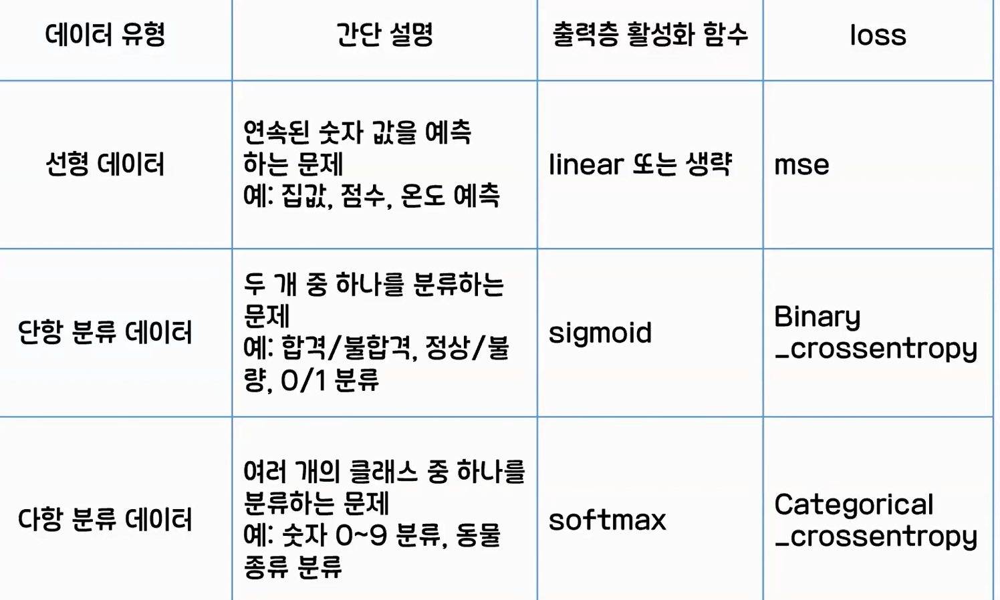

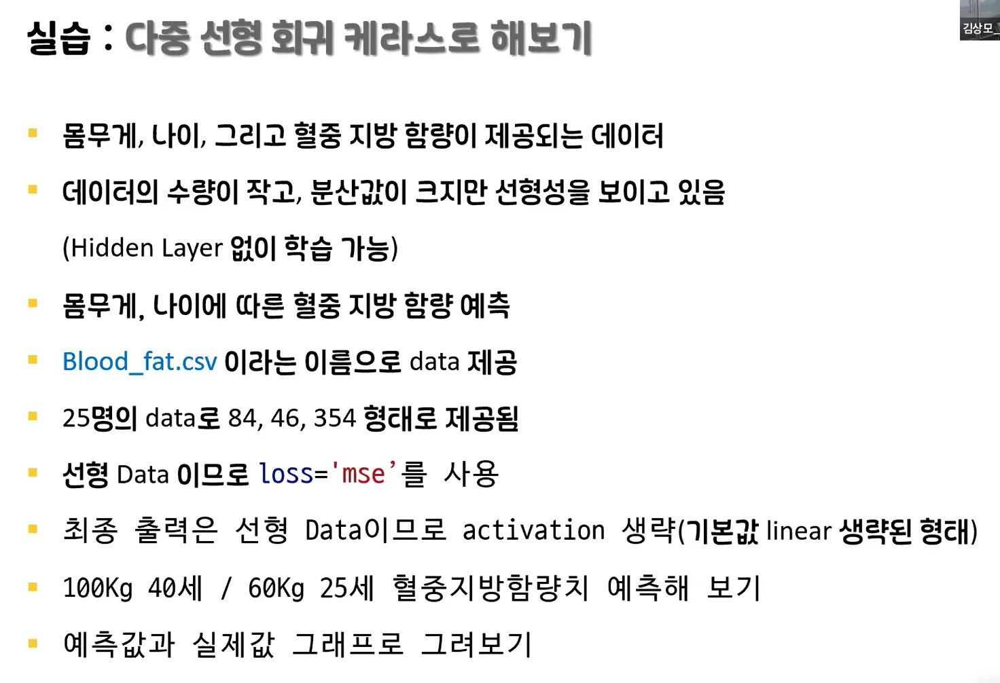

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
import numpy
import tensorflow as tf

# 시드
seed = 0
numpy.random.seed(seed)
tf.random.set_seed(seed)

# 데이터
Data_set = numpy.loadtxt("Blood_fat.csv", delimiter=",")
x_train = Data_set[:, 0:2] # 0~1 : 몸무게, 나이
x_target = Data_set[:, 2]  # 2 : 혈중농도
y_target = x_target.reshape(25, 1) # 2차원 배열로 reshape : x_target.reshape(-1, 1) -1 행의 갯수는 알아서 해라

# 옵티마이저
adam = Adam(learning_rate=0.01)

# 모델 설계
# 선형이기 때문에, Hidden layer 사용 X (Hidden layer = 비선형성)
model=Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(1))

# 모델 정보 출력
model.summary()

# 딥러닝을 실행합니다.
# 선형이기 때문에, 0 ~ 1 사이의 확률 X(단항, 다항의 로그회귀함수 X)
# 선형이기 때문에, 예측값이 실제값을 정확히 동일하게 맞출 수 없다. Accuracy X
model.compile(loss='mse', optimizer=adam)

# fit()에서는 입력, 출력의 수량이 동일하면 shape는 자동 변환된다.
# 수량이 다를 경우에는 Error가 발생한다.
hist = model.fit(x_train, y_target, epochs=300, batch_size=10)
print(hist.history.keys()) # 결과 : dict_keys(['loss'])
# history object는 훈련 중 발생되는 모든 정보를 담고있다.
# 매 에포크 마다의 훈련 손실값 (loss)
# 매 에포크 마다의 훈련 정확도 (acc)
# 매 에포크 마다의 검증 손실값 (val_loss)
# 매 에포크 마다의 검증 정확도 (val_acc)

# 결과를 출력합니다.
print("\n Loss: %4f" % (model.evaluate(x_train, y_target)))

# 모델에 넣을 입력 데이터를 2차원 배열로 변환합니다.
input_data = numpy.array([[100, 40], [60, 25]], dtype=numpy.float32)

# 예측값 출력
prediction = model.predict(input_data)
print(f" 100kg 40세 혈중지방함량 : {prediction[0]}, 60kg 25세 혈중지방함량 : {prediction[1]}")

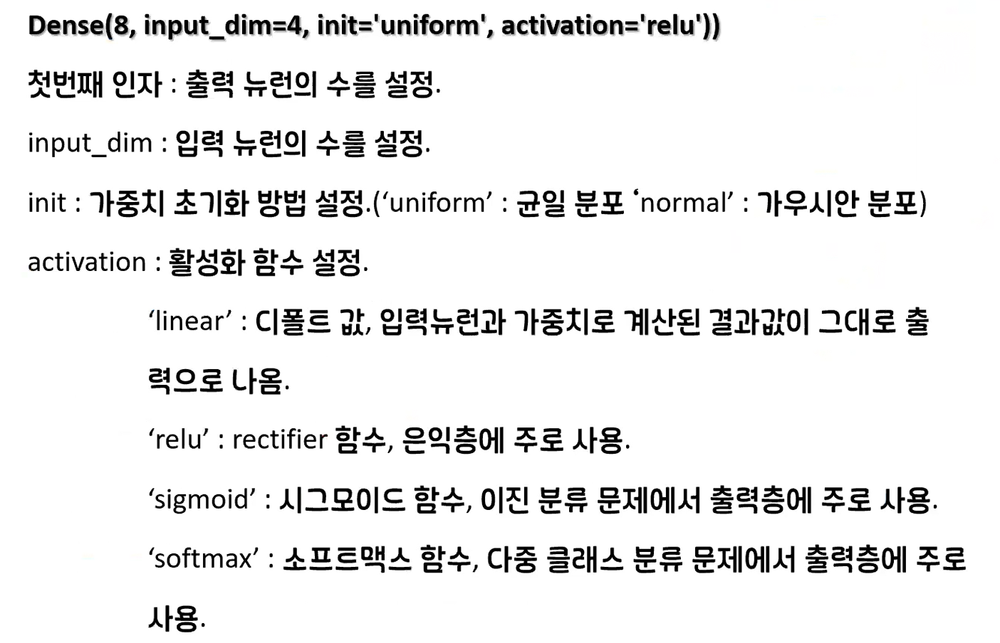

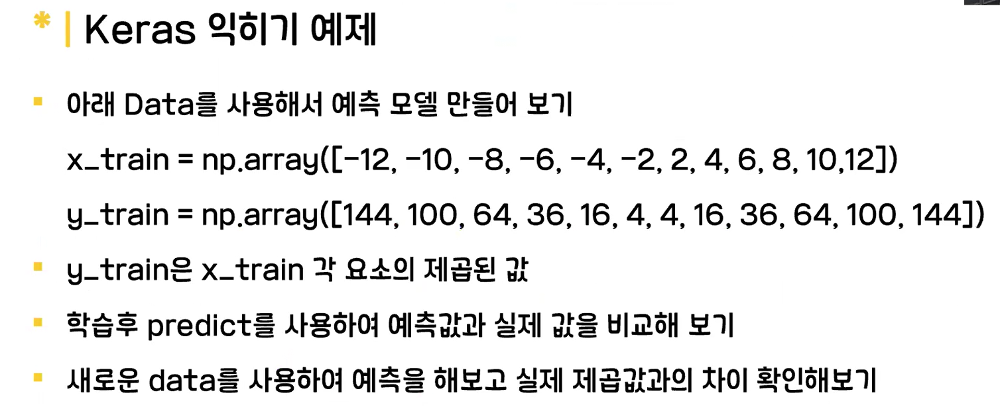

In [ ]:
# x, y 가 '제곱'이라는 규칙을 가질 때
# 데이터 만으로 스스로 규칙을 찾아서 '예측'이 가능한지

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
import numpy as np
import tensorflow as tf
import matplotlib as mlp
import matplotlib.pyplot as plt

# 시드
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# 데이터
x_train = np.array([-12, -10, -8, -6, -4, -2, 2, 4, 6, 8, 10, 12], dtype=np.float32).reshape(12, 1) # reshape(-1, 1)
y_train = np.array([144, 100, 64, 36, 16, 4, 4, 16, 36, 64, 100, 144], dtype=np.float32).reshape(12, 1) # reshape(-1, 1)

# 옵티마이저
adam = Adam(learning_rate=0.01)

# 모델 설계
model=Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(30, activation='relu'))
model.add(Dense(1))

model.compile(loss='mse', optimizer=adam)
model.fit(x_train, y_train, epochs=500, batch_size=10)

# 결과를 출력합니다.
final_loss = model.evaluate(x_train, y_train, verbose=0)
print("\n 최종 Loss(MSE): %.4f" % final_loss)

# 모델에 넣을 입력 데이터를 2차원 배열로 변환합니다.
input_data = np.array([-18, -15, -12, -9, -6, -3, 3, 6, 9, 12, 15, 18], dtype=np.float32).reshape(12, 1) # reshape(-1, 1)

# 예측값 출력
predictions = model.predict(input_data)

# 예측결과 출력
for i, input_value in enumerate(input_data) :
    print(f"Input : {input_value} 일때 -> 예측값 : {predictions[i][0]:.2f} ")

# 그래프
plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, color='blue', label='Actual')
plt.scatter(input_data, predictions, color='red', label='predicted')
plt.plot(x_train, y_train, color='blue', linestyle='dashed')
plt.xlabel('input')
plt.ylabel('output(square)')
plt.title('actual vs predicted values')
plt.show()

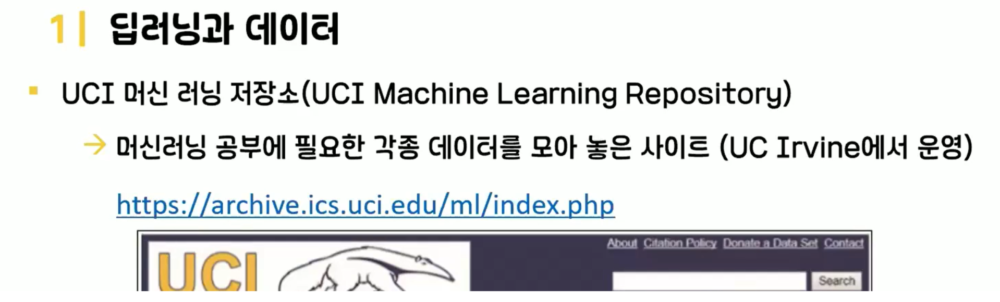

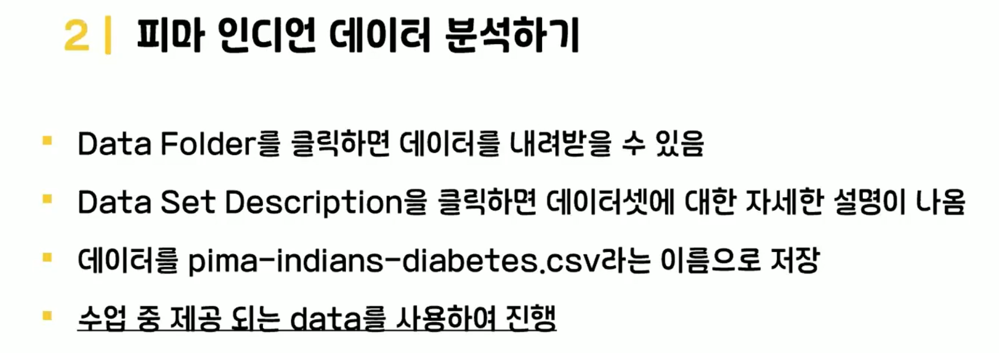

In [ ]:
# pima-indians-diabets

# 속성 1 ~ 8 : pregnant(임신 횟수), pressure(혈압)... ~ age(나이) 등등
# 클래스 : 당뇨(1), 당뇨 아님(0)

# 6,148,72,35,0,33.6,0.627,50,1
# 1,85,66,29,0,26.6,0.351,31,0
# 8,183,64,0,0,23.3,0.672,32,1
# 1,89,66,23,94,28.1,0.167,21,0
# 0,137,40,35,168,43.1,2.288,33,1

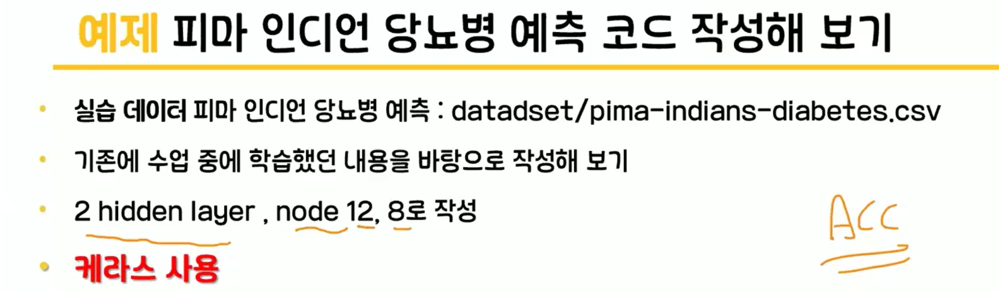

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
import numpy as np
import tensorflow as tf

# 시드
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# 데이터 : 6,148,72,35,0,33.6,0.627,50,1
dataset = np.loadtxt("pima-indians-diabetes.csv", delimiter=",", dtype=np.float32)
x_train = dataset[:700, 0:8] # 0~8 : 속성
y_train = dataset[:700, 8]   # 1 : 당뇨, 0 : 당뇨x
x_test = dataset[700:, 0:8]
y_test = dataset[700:, 8]

# 모델 설계
model=Sequential()
model.add(Input(shape=(8,)))
model.add(Dense(12, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# 모델 정보 출력
model.summary()

# 딥러닝을 실행합니다.
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# 전체 데이터 768개 중 먼저 10개를 가져와서 예측값을 구한다. 이 10개의 데이터에 대한 오차를 모아서 평균을 낸다.
# 그 평균 오차를 바탕으로 가중치를 1번 업데이트 한다.
# 즉, 300번 학습하는 동안 가중치 업데이트는 1 epoch 당 77번, 총 가중치 업데이트 횟수는 77 x 300번
model.fit(x_train, y_train, epochs=300, batch_size=10)

# 결과를 출력합니다.
scores = model.evaluate(x_test, y_test)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1] * 100))

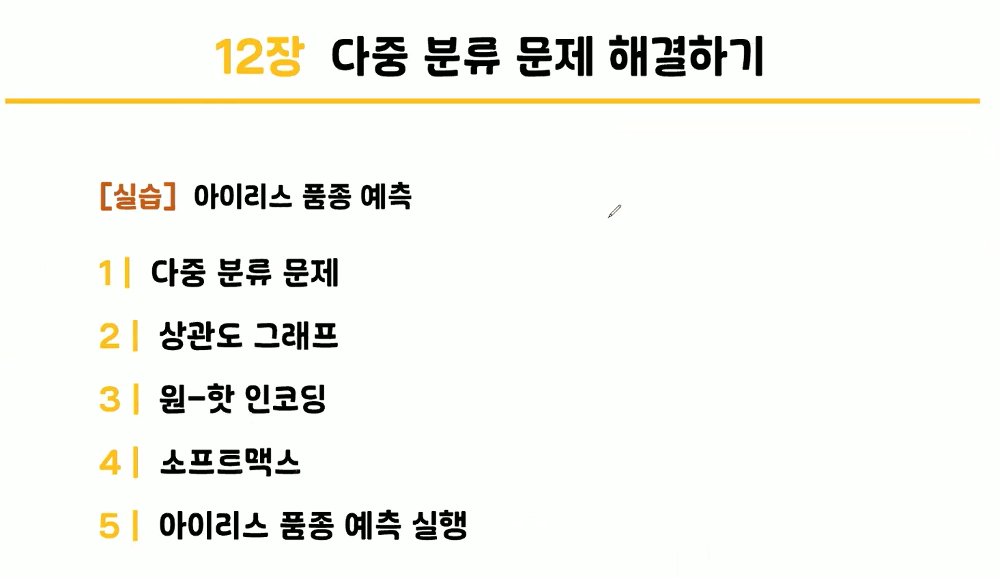

In [ ]:
# iris_data
# 속성 : 4 => 꽃받침 길이(sepal length), 꽃받침 넓이(sepal width), 꽃잎 길이(petal legnth), 꽃잎 넓이(petal width) 
# 클래스 : 3(문자) => Iris-setosa, Iris-versicolor, Iris-virginica 

# 5.1, 3.5, 1.4, 0.2, Iris-setosa 
# 7.0, 3.2, 4.7, 1.4, Iris-versicolor
# 6.3, 3.3, 6.0, 2.5, Iris-virginica

# 참(1), 거짓(0)으로 해결하는 것이 아니라, 선택지 여러 개 중에 어떤 것이 답인지를 예측해야 한다.
# 다중 분류!!

In [ ]:
import pandas as pd

df = pd.read_csv('iris.csv', names = ["sepal_length", "sepal_width", "petal_legnth", "petal_width", "species"])
# print(df)

import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue='species')
plt.show()

# iris_setosa만 따로 떨어져 있는 모습 확인
# iris_versicolor, iris_virginica는 구분 어려울거라는 예상
# W, b : 가중치를 찾아서 3개의 클래스 분류하기

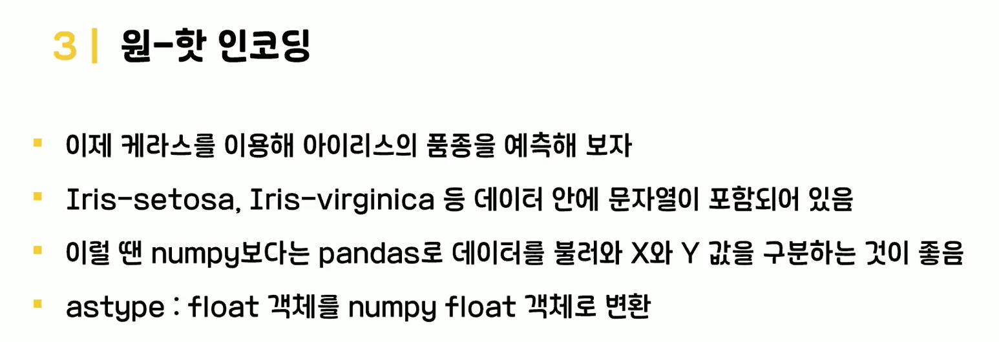

In [ ]:
import pandas as pd

df = pd.read_csv('iris.csv', names = ["sepal_length", "sepal_width", "petal_legnth", "petal_width", "species"])
# print(df.values) ## [[속성1, 속성2, 속성3, 속성4, 클래스]]

# 데이터 읽어 들인 후(object)
# dataframe -> class
# dataframe.values -> numpy배열
dataset = df.values

# 정수인 속성은 float으로 데이터 형식이 '숫자'임을 명시
# object는 그냥 object
X = dataset[:, 0:4].astype(float)
# 문자인 클래스는? object -> 형 변환 전
Y_obj = dataset[:, 4]

from sklearn.preprocessing import LabelEncoder
# 문자 -> 숫자, 형 변환
# fit -> 준비
# transform -> 땅
e = LabelEncoder()
e.fit(Y_obj)
Y = e.transform(Y_obj)
# print(Y)
# [iris_setosa, iris_versicolor, iris_virginica] => [0, 1, 2] : 0, 1, 2 순... 선형데이터로 분석 된다. 변경 필요

import tensorflow as tf
# 원-핫 인코딩
# 활성화 함수를 적용하려면 Y값이 0과 1로 이루어져 있어야 한다.
# tf.keras.utils.to_categorical()
# [0, 1, 2] -> [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
Y_encoded = tf.keras.utils.to_categorical(Y)
# print(Y_encoded)

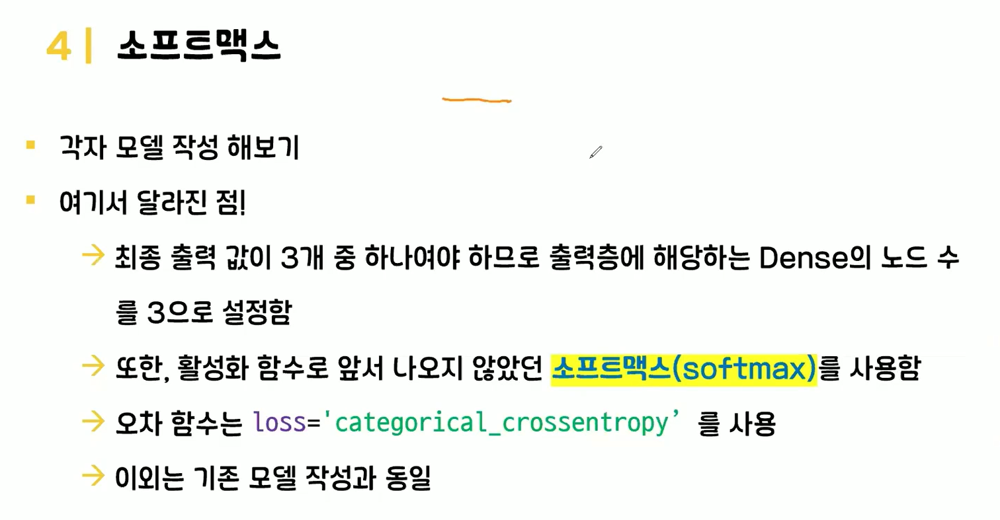

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder
import numpy as np
import tensorflow as tf
import pandas as pd

# 시드
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# 데이터
# 5.1, 3.5, 1.4, 0.2, Iris-setosa
# 7.0, 3.2, 4.7, 1.4, Iris-versicolor
# 6.3, 3.3, 6.0, 2.5, Iris-virginica
df = pd.read_csv('iris.csv', names = ["sepal_length", "sepal_width", "petal_legnth", "petal_width", "species"])
dataset = df.values

X = dataset[:, 0:4].astype(float) # 숫자
Y_obj = dataset[:, 4] # 문자

# 문자 -> 숫자
e = LabelEncoder()
e.fit(Y_obj)
Y = e.transform(Y_obj)

# 선형 데이터 -> 원 핫 인코딩으로
Y_encoded = tf.keras.utils.to_categorical(Y)

X_train = X[:130, 0:4]
y_train = Y_encoded[:130, :3]
X_test = X[130:, 0:4]
y_test = Y_encoded[130:, :3]

# 모델 설계
model=Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(12, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))

# 모델 정보 출력
model.summary()

# 딥러닝을 실행합니다.
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=100, batch_size=10)

# 결과를 출력합니다.
scores = model.evaluate(X_test, y_test)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1] * 100))

# 새로운 데이터 정의
new_data = np.array([
    [5.4, 3.9, 1.7, 0.4],
    [5.2, 2.7, 3.9, 1.4],
    [6.4, 2.8, 5.6, 2.1],
])

# 예측 수행
pred = model.predict(new_data)

# 확률에서 가장 큰 값을 가지는 클래스 인덱스 추출
pred_labels = np.argmax(pred, axis=1)

# 숫자 인덱스를 원래 품종 이름으로 다시 변환
pred_species = e.inverse_transform(pred_labels)

# 예측 결과 출력
for i, species in enumerate(pred_species) :
    print(f"샘플 {i+1} : 예측 품종 -> {species}")

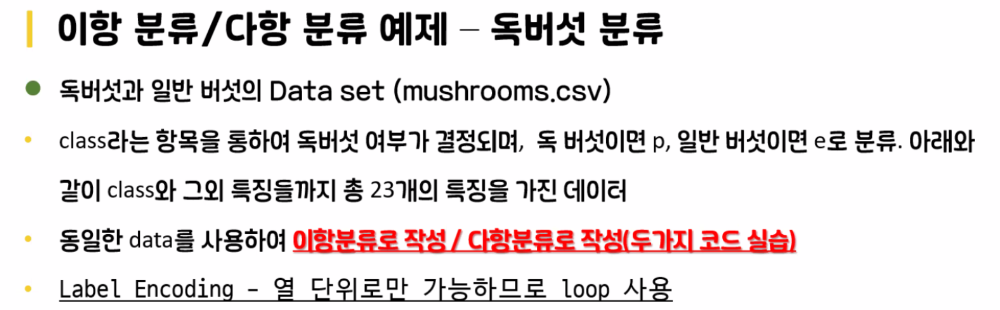

In [ ]:
## 단항 - 나

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder
import numpy as np
import tensorflow as tf
import pandas as pd

# 시드
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# 데이터 : p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
# 클래스 0, 속성 1 ~ 22
df = pd.read_csv('mushrooms.csv')
dataset = df.values

X_obj = dataset[:, 1:]
Y_obj = dataset[:, 0]

X_encoded = np.zeros(X_obj.shape) #shape : Numpy, Pandas에서 이 데이터 표의 크기가 가로, 세로 각각 몇칸인지, [0]:행, [1]:열
for i in range(22) :
    le_x = LabelEncoder()
    le_x.fit(X_obj[:, i])
    X_encoded[:, i] = le_x.fit_transform((X_obj[:, i]))
# print(X_encoded)

e = LabelEncoder()
e.fit(Y_obj)
Y = e.transform(Y_obj)
# print(Y_encoded)

# 모델 구성하기
model=Sequential()
model.add(Input(shape=(22,)))
model.add(Dense(12, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# 모델 정보 출력
model.summary()

# 딥러닝을 실행합니다.
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_encoded, Y, epochs=10, batch_size=10)

# 결과를 출력합니다.
scores = model.evaluate(X_encoded, Y)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1] * 100))

In [ ]:
## 단항 - 강사님

In [ ]:
import pandas as pd

mushrooms = pd.read_csv('mushrooms.csv')
# print(mushrooms)

# Label-Encoding - 열 단위로만 기능하므로, loop 사용
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()
for col in mushrooms.columns:
    labelencoder.fit(mushrooms[col])
    mushrooms[col] = labelencoder.transform(mushrooms[col]) # fit_transform

y = mushrooms['class'].values
x = mushrooms.drop(['class'], axis=1) # drop : 특정 열 삭제, axis=1 : '열'기준, axis=0 : '행'기준
x = x.values

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split

# 시드
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# 데이터
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=seed)
# print("x_train.shape :", x_train.shape)
# print("y_train.shape :", y_train.shape)
# print("x_test.shape :", x_test.shape)
# print("y_test.shape :", y_test.shape)

# 모델
model = Sequential()
model.add(Input(shape=(22,)))
model.add(Dense(48, activation='relu'))
model.add(Dense(24, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
histroy = model.fit(x_train, y_train, epochs=10, batch_size=32)

model.summary()

# 검증
model.evaluate(x_test, y_test)

In [ ]:
## 다항 - 나

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder
import numpy as np
import tensorflow as tf
import pandas as pd

# 시드
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# 데이터 : p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
# 클래스 0, 속성 1 ~ 22
df = pd.read_csv('mushrooms.csv')
dataset = df.values

X_obj = dataset[:, 1:]
Y_obj = dataset[:, 0]

X_encoded = np.zeros(X_obj.shape) #shape : Numpy, Pandas에서 이 데이터 표의 크기가 가로, 세로 각각 몇칸인지, [0]:행, [1]:열
for i in range(22) :
    le_x = LabelEncoder()
    le_x.fit(X_obj[:, i])
    X_encoded[:, i] = le_x.fit_transform((X_obj[:, i]))
# print(X_encoded)

e = LabelEncoder()
e.fit(Y_obj)
Y = e.transform(Y_obj)
Y_encoded = tf.keras.utils.to_categorical(Y)
# print(Y_encoded)

# 모델 구성하기
model=Sequential()
model.add(Input(shape=(22,)))
model.add(Dense(12, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(2, activation='softmax'))

# 모델 정보 출력
model.summary()

# 딥러닝을 실행합니다.
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_encoded, Y_encoded, epochs=10, batch_size=10)

# 결과를 출력합니다.
scores = model.evaluate(X_encoded, Y_encoded)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1] * 100))

In [ ]:
## 다항 - 강사님

In [ ]:
import pandas as pd

mushrooms = pd.read_csv('mushrooms.csv')
# print(mushrooms)

# Label-Encoding - 열 단위로만 기능하므로, loop 사용
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()
for col in mushrooms.columns:
    labelencoder.fit(mushrooms[col])
    mushrooms[col] = labelencoder.transform(mushrooms[col]) # fit_transform

y = mushrooms['class'].values
x = mushrooms.drop(['class'], axis=1) # drop : 특정 열 삭제, axis=1 : '열'기준, axis=0 : '행'기준
x = x.values

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split

# 시드
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# 데이터
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=seed)
# print("x_train.shape :", x_train.shape)
# print("y_train.shape :", y_train.shape)
# print("x_test.shape :", x_test.shape)
# print("y_test.shape :", y_test.shape)

# Binary를 Multi-class로
y_train = tf.keras.utils.to_categorical(y_train, num_classes=2)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=2)
# print("============ to_categorical 이후 =====================")
# print("y_train.shape =", y_train.shape)
# print("y_test.shape =", y_test.shape)

# 모델
model = Sequential()
model.add(Input(shape=(22,)))
model.add(Dense(48, activation='relu'))
model.add(Dense(24, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
histroy = model.fit(x_train, y_train, epochs=10, batch_size=32)

model.summary()

# 검증
model.evaluate(x_test, y_test)

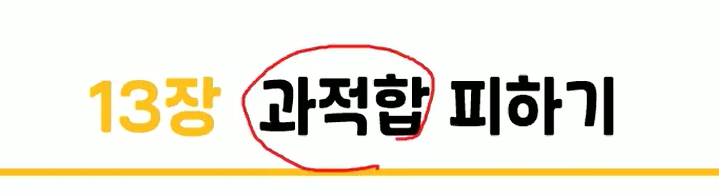

In [ ]:
# 과적합 : 모델이 학습 데이터셋 안에서는 일정 수준 이상의 예측 정확도를 보이지만,
# 새로운 데이터에 적용하면 잘 맞지 않는 상태를 말한다.

# 너무 많은 노드, 레이어
# 너무 많은 학습

# 과적합 방지 : 학습(Train), 검증(Validation), 테스트(Test)로 데이터를 구분한다.
# 과적합 방지 : 노드나 레이어를 학습 중간에 없애는 건 불가능하기 떄문에... 과적합이 되기 전에 학습을 멈춰야 한다.
# 밑에 이미지 확인

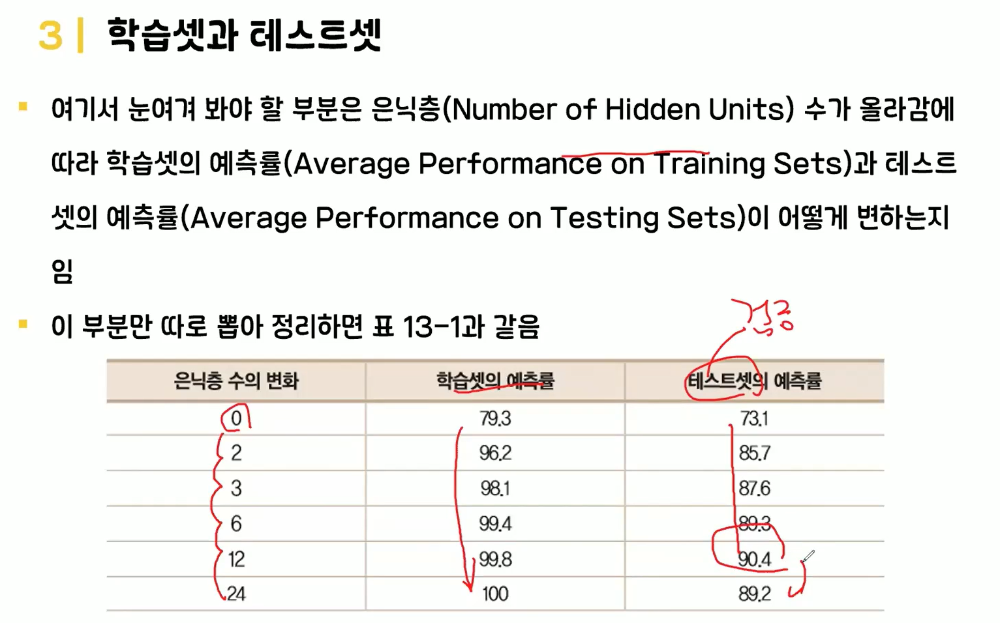

In [ ]:
# 초음파로 광물 예측하기

In [ ]:
import pandas as pd

# Index 208
# total 61 columns
# 60 208 non-null object -> class, 나머지는 float64타입의 속성 
df = pd.read_csv('sonar.csv', header=None) # 파일이 첫 줄 항목이 아니고 모두 데이터일 때
print(df.info())

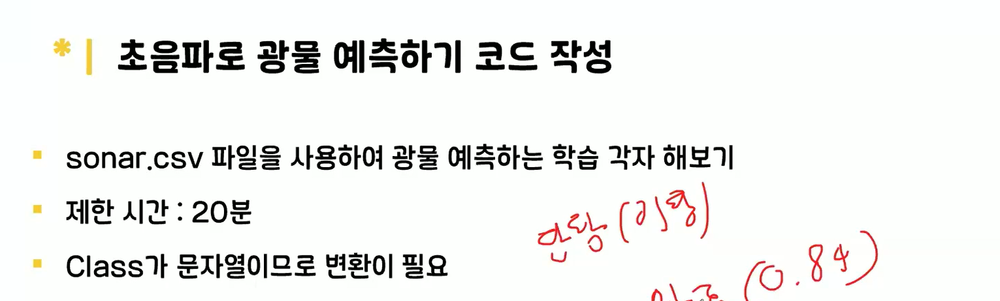

In [ ]:
import pandas as pd
df = pd.read_csv('sonar.csv', header=None)
# print(sonars.info)

# Label-Encoding
from sklearn.preprocessing import LabelEncoder

x = df.iloc[:, :-1].values.astype(float)
y_raw = df.iloc[:, -1].values

labelencoder = LabelEncoder()
y = labelencoder.fit_transform(y_raw)

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split

# 시드
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# 데이터
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=seed)
# print("x_train.shape :", x_train.shape)
# print("y_train.shape :", y_train.shape)
# print("x_test.shape :", x_test.shape)
# print("y_test.shape :", y_test.shape)

# 모델
model = Sequential()
model.add(Input(shape=(60,)))
model.add(Dense(48, activation='relu'))
model.add(Dense(24, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
histroy = model.fit(x_train, y_train, epochs=50, batch_size=32)

model.summary()

# 검증
model.evaluate(x_test, y_test)

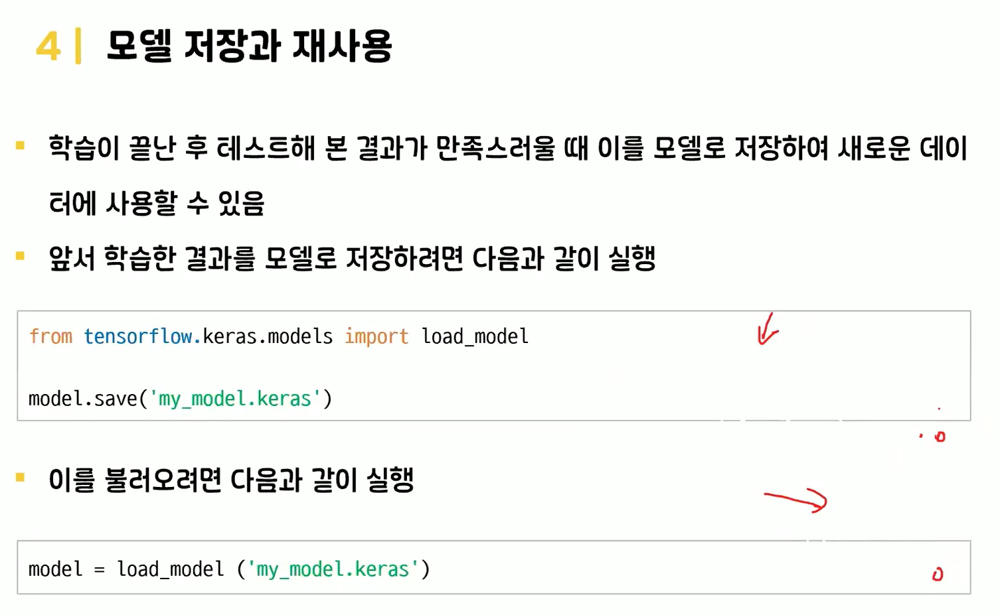

In [ ]:
import pandas as pd
df = pd.read_csv('sonar.csv', header=None)
# print(sonars.info)

# Label-Encoding
from sklearn.preprocessing import LabelEncoder

x = df.iloc[:, :-1].values.astype(float)
y_raw = df.iloc[:, -1].values

labelencoder = LabelEncoder()
y = labelencoder.fit_transform(y_raw)

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split

# 시드
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# 데이터
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=seed)
# print("x_train.shape :", x_train.shape)
# print("y_train.shape :", y_train.shape)
# print("x_test.shape :", x_test.shape)
# print("y_test.shape :", y_test.shape)

# 모델
model = Sequential()
model.add(Input(shape=(60,)))
model.add(Dense(48, activation='relu'))
model.add(Dense(24, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=50, batch_size=10)

# 모델 저장
model.save('my_model.keras')
print("모델이 'my_model.keras' 파일로 저장되었습니다.")